# Trabalho Computacional 2. Perceptron Multicamada no problema MNIST

## Nome: 
## Matrícula: 241024295

#### 1. Introdução e Preparação

Faremos uso do MLP para o problema de classificação de dígitos manuscritos MNIST. O código apresentado nestas instruções devem ser visto como sugestão, mas o trabalho deve necessariamente estar em python, na forma de um "notebook", e implementar o perceptron multicamada com as características dadas para resolver o problema dado. 

Além das sugestões dadas aqui, observe o caderno de implementação do MLP no problema Fashion_MNIST que estudamos em sala. 

Começamos com os módulos necessários:

In [1]:
import torch
import torchvision
from torchvision import transforms
from d2l import torch as d2l
from torch import nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from math import ceil
from math import sqrt
from torch.nn import functional as F
import numpy as np


Não é necessário desta vez usar um arquivo em disco, porque a base de dados MNIST está disponível como um dos conjuntos de dados do pytorch. 

In [2]:
class MNIST(d2l.DataModule):  #@save
    """The Fashion-MNIST dataset."""
    def __init__(self, batch_size=64, resize=(28, 28)):
        super().__init__()
        self.save_hyperparameters()
        trans = transforms.Compose([transforms.Resize(resize),
                                    transforms.ToTensor()])
        self.train = torchvision.datasets.MNIST(
            root=self.root, train=True, transform=trans, download=True)
        self.val = torchvision.datasets.MNIST(
            root=self.root, train=False, transform=trans, download=True)

Há 60.000 exemplos de treinamento e 10.000 de validação. A entrada, em cada exemplo, é uma matriz 28x28 de pixels. As imagens originais manuscritas foram pré-processadas (normalizadas em tamanho e centralizadas). 

In [3]:
dataset = MNIST()
print(len(dataset.train), len(dataset.val))
print(dataset.train.data.shape)

60000 10000
torch.Size([60000, 28, 28])


Abaixo um código, do d2l, para ler um minibatch de um dado tamanho. Em cada chamada, ele nos dá o tensor de entrada X e a classe desejada y. 
Ele também embaralha os dados no momento do treinamento.

In [4]:
@d2l.add_to_class(MNIST)  #@save
def get_dataloader(self, train):
    data = self.train if train else self.val
    return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train,
                                       num_workers=self.num_workers)

Vamos usar isso com um minibatch e ver as dimensões

In [5]:
X, y = next(iter(dataset.train_dataloader()))
print(X.shape, X.dtype, y.shape, y.dtype)

torch.Size([64, 1, 28, 28]) torch.float32 torch.Size([64]) torch.int64


Você pode estranhar a princípio as dimensões de X. São 64 imagens 28x28, mas por que a dimensão unitária adicional? Lembre-se que, em geral, imagens têm 3 canais de cor. Estas imagens são em tons de cinza. 

## 2. Modelos e Arquiteturas

Para a implementação, baseie-se na classe MLP definida no caderno que vimos em sala de aula. A primeira camada deve ser do tipo "Flatten" como no outro exemplo. Ela transforma a matriz 28x28 em um vetor unidimensional de tamanho 784. Neste trabalho, vocês farão algumas variações de arquitetura, funções de ativação e algoritmos de treinamento, indo das técnicas usadas nas primeiras aplicações do Perceptron nos anos 80/90 às atuais. Para cada uma delas, avalie a acurácia, sobre o arquivo de validação, do modelo treinado. 

Eu não estou sugerindo que cada modificação introduzida vai necessariamente melhorar o modelo em todas as ocasiões. Lembre-se, também, que um valor melhor em um único treinamento pode não ter significância estatística. **Haverá bonificação se essas análises foram feitas para mais de uma rodada de treinamento (com valores de inicialização aleatória diferentes).** 

### 2a) Perceptron com uma camada escondida, função de ativação sigmoide e otimização por descida de gradiente.

Comecemos com um MLP com uma camada escondida de 128 neurônios. Usaremos a **função logística** (sigmoide) como função de ativação na camada escondida e softmax na camada de saída (lembre que a camada de saída pode na verdade ser declarada linear, pois o pytorch já aplica o softmax na implementação da função de custo de entropia cruzada, como vimos em sala). Mantenha entropia cruzada como função de custo e a descida simples de gradiente como otimizador. 

### 2b) Otimizador Adam

O gradiente simples tem um inconveniente grave: sabemos que melhoramos o desempenho do classificador se acompanharmos o gradiente em um "pequeno passo", mas não é fácil determinar que passo deveria ser esse. E sabemos que ele deveria variar ao longo do treinamento. Várias propostas para uma adaptação da taxa de aprendizado foram feitas, mas a que acabou se tornando padrão é o chamado otimizador Adam (Kingma and Ba, 2014). O nome vem de "Estimativa adaptativa de momentos". Acompanhando a média e variância do gradiente entre atualizações, ele consegue adaptar a taxa de aprendizado, e torná-la diferente para cada parâmetro. 

Redefina a função `configure_optimizers` dentro da classe `MLP` e nela use agora `torch.optim.Adam` como o otimizador. Retreine e reavalie. 

### 2c) A função Relu

Um desenvolvimento um tanto surpreendente foi a descoberta de que uma simples função retificadora (0 se a soma é negativa, função identidade se é positiva) nos dá não-linearidade suficiente para o MLP. Use a **ReLU** como função de ativação na camada oculta. Retreine e reavalie. 

### 2d) Redes maiores

Com esses desenvolvimentos, e a melhoria geral na capacidade de computação, aos poucos foi possível trabalhar com redes cada vez maiores. Experimente uma camada escondida com 256 neurônios, e também uma rede com duas camadas escondidas. Retreine e reavalie. 

In [6]:
class Classifier(d2l.Module):  #@save
    """The base class of classification models."""
    def validation_step(self, batch):
        Y_hat = self(*batch[:-1])
        self.plot('loss', self.loss(Y_hat, batch[-1]), train=False)
        self.plot('acc', self.accuracy(Y_hat, batch[-1]), train=False)

### 2a) Perceptron com uma camada escondida, função de ativação sigmoide e otimização por descida de gradiente.

In [7]:
class Psg(d2l.Classifier): #@save
    def __init__(self, lr, hidden_amount = 128):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(nn.Flatten(), nn.LazyLinear(hidden_amount), nn.Sigmoid(), nn.LazyLinear(10))

    def foward(self, X):
        return self.net(X)

    def loss(self, Y_hat, Y, averaged=True):
        Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
        Y = Y.reshape((-1,))
        return F.cross_entropy(
            Y_hat, Y, reduction='mean' if averaged else 'none')

    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(), lr=self.lr)        

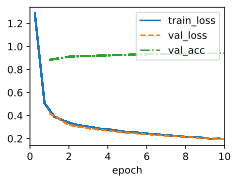

In [60]:
model  = Psg(0.1)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model,dataset)

### 2b) Otimizador Adam

In [67]:
class Adam(Psg):
    def __init__(self):
        super().__init__(0.1)
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)
    

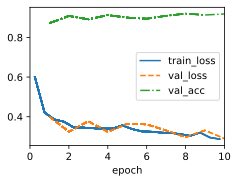

In [68]:
model  = Adam()
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model,dataset)

### 2c) Relu

In [8]:
class Reluz(Psg):
    def __init__(self):
        super().__init__(0.1)
        self.net = nn.Sequential(nn.Flatten(), nn.LazyLinear(128), nn.ReLU(), nn.LazyLinear(10))

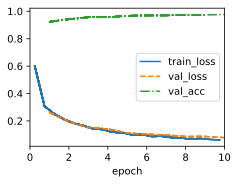

In [72]:
model  = Reluz()
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model,dataset)

### 2d) Redes Maiores

In [13]:
class Psg256(Psg):
    def __init__(self):
        super().__init__(0.1, 256)

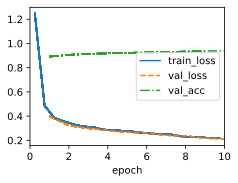

In [14]:
model  = Psg256()
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model,dataset)

In [15]:
class Psg2Layers(Psg):
    def __init__(self):
        super().__init__(0.1)
        self.net = nn.Sequential(nn.Flatten(), nn.LazyLinear(128), nn.ReLU(), nn.LazyLinear(128), nn.ReLU())

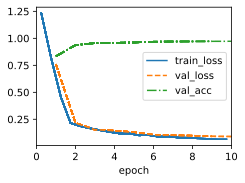

In [16]:
model  = Psg2Layers()
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model,dataset)

## 3. Visualização 

Gostaríamos agora de observar alguns dos exemplos mal-classificados. Você pode se basear na função `.visualize` do exemplo visto em sala, mas adaptações são necessárias. Em primeiro lugar, naquela ocasião usamos apenas os erros de um minibatch. Como o desempenho daquele classificador foi relativamente fraco, havia erros em todos os "minibatches". O MLP (especialmente os maiores) deve ter um número pequeno de erros, e é possível que não haja nenhuma classificação errada em um dado minibatch. Isso produziria um erro no seu código.  

Além disso, queremos talvez visualizar o erro não apenas no último minibatch. Faça um código que passe por todos os minibatches (por exemplo, `for X, y in dataset.val_dataloader()`) e identifique exemplos de classificações incorretas. Ou então, trabalhe diretamente com o objeto MNIST `dataset`. Neste caso, lembre-se que `dataset.train` e `dataset.val` são ambas "duplas", contendo as entradas e as saídas de todos os exemplos.  Usar o iterador como `dataset.val_dataloader()` torna-se essencial quando usarmos grandes bases de dados e não pudermos trazer e alocar tudo em memória de uma vez.

Há um outro problema na implementação feita em sala. `dataset.visualize` espera uma lista de imagens, e não vai funcionar com uma imagem única. Assim como pode haver minibatches sem erros, pode haver minibatches com um erro a visualizar apenas. Nestes casos talvez as funções `imshow` e `show` do módulo `matplotlib.pyplot` possam ser úteis. 

Seja como for, mostre alguns padrões erradamente classificados (juntamente com os rótulos esperados e obtidos, como vimos no exemplo em sala de aula). Você acha que é razoável que um humano cometesse esse tipo de erro? 

In [9]:
@d2l.add_to_class(MNIST)  #@save
def text_labels(self, indices):
    """Return text labels."""
    labels = ['0', '1', '2', '3', '4','5',
              '6', '7', '8', '9']
    return [labels[int(i)] for i in indices]

C:\Users\spiri\miniconda3\envs\d2l\lib\site-packages\torch\nn\modules\lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
C:\Users\spiri\AppData\Local\Temp\ipykernel_9684\1324670506.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


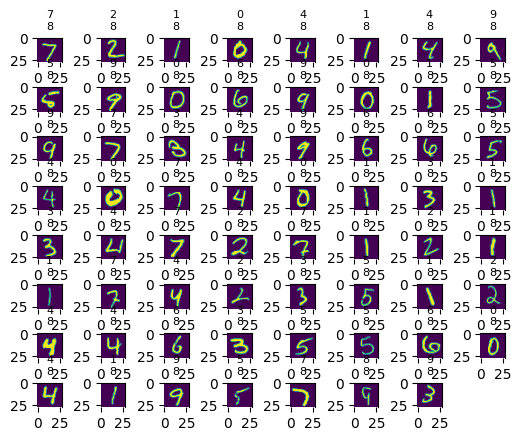

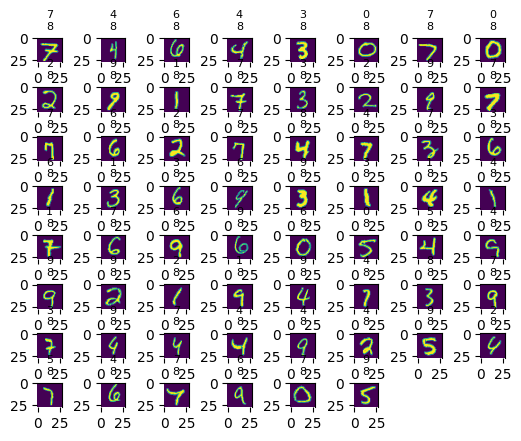

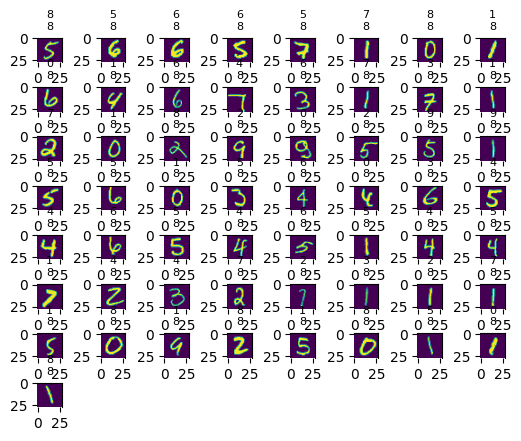

In [ ]:
model = Psg(0.1)
for X,y in dataset.val_dataloader():
    preds = model(X).argmax(axis=1)
    wrongs = preds != y
    wrongX, wrongY, predsMatrix = X[wrongs].squeeze(1), y[wrongs], preds[wrongs]
    labels = [a+'\n'+b for a, b in zip(
    dataset.text_labels(y), dataset.text_labels(preds))]
    fig = plt.figure()
    size = wrongX.size(0)
    mini = ceil(sqrt(size))
    for i in range(0, size):
        sub = plt.subplot(mini, mini,i +1 )
        sub.spines['left'].set_visible(False)
        sub.spines['bottom'].set_visible(False)
        plt.title(labels[i], fontsize= 8)
        plt.imshow(wrongX[i])
    fig.subplots_adjust(hspace=1)
plt.show()

    
    

## 4. Matriz de confusão

Queremos agora observar a matriz de confusão do seu melhor classificador. A função `confusion_matrix` do módulo `sklearn.metrics` faz esse cálculo, mas temos de novo o problema que essa função espera receber todos as classes corretas (`y`) e todas as predições (`preds`) de uma vez. De novo, faça isso para cada minibatch usando o iterador `dataset.val_dataloader()` e depois combine-as corretamente, ou então trabalhe diretamente com as duplas no objeto `dataset`. 

Obtenha a matriz de confusão (10x10). Observe o resultado. Quais são as "confusões" mais comuns para cada classe (ou seja, para cada classe i qual a classe j é a atribuição errada mais comum? Isso faz sentido?



In [16]:
model = Reluz()
yay = []
for X,y in dataset.val_dataloader():
    preds = model(X).argmax(axis=1)
    conf_matrix = confusion_matrix (y, preds)
    if conf_matrix.shape == (9,9):
        conf_matrix=  np.append(conf_matrix, [[0,0,0,0,0,0,0,0,0]],axis=0)
        conf_matrix = np.append(conf_matrix, [[0],[0],[0],[0],[0],[0],[0],[0],[0], [0]],axis=1)
    yay.append(conf_matrix)

matriz = np.mean(yay, axis=0)
with np.printoptions(precision=3, suppress=True):
    print(matriz)

for i in range(0, matriz.shape[0]):
    maximo = np.argmax(matriz[i])
    print("Classe " + str(i) + " Classe errada mais comum: " + str(maximo))
    

C:\Users\spiri\miniconda3\envs\d2l\lib\site-packages\torch\nn\modules\lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


[[0.006 0.    0.019 0.    5.025 1.038 0.    0.    0.153 0.   ]
 [0.    0.    0.    0.    2.306 4.924 0.    0.    0.    0.   ]
 [0.    0.    0.032 0.    4.955 1.573 0.    0.006 0.006 0.   ]
 [0.    0.    0.013 0.    3.159 3.255 0.    0.006 0.    0.   ]
 [0.    0.    0.019 0.013 5.688 0.522 0.    0.013 0.    0.   ]
 [0.    0.    0.045 0.    3.554 2.057 0.    0.025 0.    0.   ]
 [0.    0.    0.019 0.006 4.739 1.331 0.    0.006 0.    0.   ]
 [0.    0.    0.006 0.    5.701 0.866 0.    0.019 0.    0.   ]
 [0.013 0.    0.057 0.    2.465 3.669 0.    0.019 0.006 0.   ]
 [0.    0.    0.006 0.    4.465 1.879 0.    0.006 0.    0.   ]]
Classe 0 Classe errada mais comum: 4
Classe 1 Classe errada mais comum: 5
Classe 2 Classe errada mais comum: 4
Classe 3 Classe errada mais comum: 5
Classe 4 Classe errada mais comum: 4
Classe 5 Classe errada mais comum: 4
Classe 6 Classe errada mais comum: 4
Classe 7 Classe errada mais comum: 4
Classe 8 Classe errada mais comum: 5
Classe 9 Classe errada mais comum: 4